## 📊 A/B Testing Analysis: Evaluating a New Website Design

###  Objective
The goal of this project is to evaluate whether a new website design (treatment group) performs better than the existing design (control group) in terms of user conversion.

###  Problem Statement
Businesses often introduce new features or design changes to improve user engagement and conversions. However, observed improvements may be due to randomness rather than actual impact. Therefore, it is important to use statistical methods to determine whether the observed difference is significant.

### Dataset Description
The dataset contains user-level information from an A/B test experiment, where:
- **Control group** users were shown the old version of the webpage
- **Treatment group** users were shown the new version of the webpage
- The column **`converted`** indicates whether a user completed the desired action (1 = converted, 0 = not converted)

###  Approach
This analysis follows a structured approach:
1. Data loading and understanding  
2. Conversion rate comparison  
3. Hypothesis testing (p-value)  
4. Confidence interval estimation  
5. Simulation to understand randomness  
6. Power analysis  
7. Segmentation analysis  
8. Business insights  

###  Goal
To determine whether the new design leads to a statistically significant and practically meaningful improvement in conversion rate.

In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv('AB Testing Data.csv')

In [4]:
df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


## 📂 Data Understanding

In this step, we load the dataset and explore its structure to understand the variables involved in the A/B testing experiment.

Each row in the dataset represents a user interaction, including:
- The group assignment (control or treatment)
- The page version shown (old or new)
- Whether the user converted or not

Understanding the dataset is important before performing any statistical analysis.

In [5]:
df.columns

Index(['user_id', 'timestamp', 'group', 'landing_page', 'converted', 'age',
       'gender', 'location', 'session_duration', 'pages_visited',
       'device_type', 'purchase_amount'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  object 
 1   timestamp         294478 non-null  object 
 2   group             294478 non-null  object 
 3   landing_page      294478 non-null  object 
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  object 
 7   location          294478 non-null  object 
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  object 
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 27.0+ MB


## 📈 Conversion Rate Analysis

In A/B testing, the key metric used to evaluate performance is the **conversion rate**, which represents the proportion of users who completed the desired action.

{Conversion Rate} = {Number of Conversions} / {Total Users}


In this step, we calculate the conversion rates for both:
- **Control group (old design)**
- **Treatment group (new design)**

This allows us to compare the performance of the two versions and observe any difference in user behavior.

In [7]:
df.groupby('group')['converted'].mean()*100

group
control      11.872643
treatment    17.948926
Name: converted, dtype: float64

In [8]:
conversion_rates= df.groupby('group')['converted'].mean()
diff= conversion_rates['treatment']- conversion_rates['control']
diff

np.float64(0.060762831086630165)

## 📊 Interpretation of Conversion Rates

The conversion rates for the two groups are:

- Control group: **11.87%**
- Treatment group: **17.95%**

The treatment group shows a higher conversion rate compared to the control group.

###  Initial Insight:
This suggests that the new design may be more effective in encouraging users to convert.

However, this observed difference could still be due to **random sampling variability**, so further statistical analysis is required to determine whether the difference is significant.

##  Difference in Conversion Rates

To quantify the improvement, we compute the difference between treatment and control conversion rates.

\[
\text{Difference} = \text{Conversion Rate (Treatment)} - \text{Conversion Rate (Control)}
\]

This helps us measure how much better (or worse) the new version performs compared to the old version.

## 📊 Interpretation of Difference

The observed difference in conversion rates is approximately **6.08%**.

This means that the new design increases the conversion rate by about 6 percentage points compared to the old design.

###  Important Note:
While this difference appears meaningful, it is important to determine whether it is due to a real effect or simply due to randomness.

This will be addressed using hypothesis testing in the next step.

##  Hypothesis Testing

To determine whether the observed difference in conversion rates is statistically significant, we perform hypothesis testing.

###  Hypotheses:

- **Null Hypothesis (H₀):** There is no difference between control and treatment  
- **Alternative Hypothesis (H₁):** There is a difference between control and treatment  

###  Idea:
Even if both groups are truly equal, we may still observe some difference due to **random sampling variability**.

The goal of hypothesis testing is to determine whether the observed difference is:
- Due to randomness  
- Or due to a real effect  

We use the **p-value** to make this decision.

In [9]:
from statsmodels.stats.proportion import proportions_ztest

# number of conversions in each group
counts = df.groupby('group')['converted'].sum()

# number of users in each group
nobs = df.groupby('group')['converted'].count()

# perform test
stat, p_value = proportions_ztest(counts, nobs)

print("Z-stat:", stat)
print("P-value:", p_value)

Z-stat: -46.277339891305736
P-value: 0.0


## 📊 Interpretation of Hypothesis Test

The results of the hypothesis test are:

- Z-statistic: **-46.28**
- P-value: **~0.0**

### Understanding the p-value:

The p-value represents the probability of observing a difference as large as (or larger than) the one observed, assuming that there is actually no difference between the two groups.

###  Interpretation:

- The p-value is extremely small (close to 0)
- This means that such a large difference is **extremely unlikely** under the assumption that both groups are equal

###  Conclusion:

Since the p-value is much smaller than the significance level (0.05), we:

- **Reject the null hypothesis**
- Conclude that the observed difference is **statistically significant**

### Final Insight:

The new design (treatment group) performs significantly better than the old design (control group), and the improvement is not due to random chance.

## Confidence Interval Estimation

While hypothesis testing tells us whether an effect exists, it does not tell us the magnitude of the effect.

To understand this, we compute a **confidence interval (CI)** for the difference in conversion rates.

###  Definition:
A confidence interval provides a range of plausible values for the true difference between treatment and control.

###  Interpretation:
- If the interval includes **0** → no difference is possible → not significant  
- If the interval does NOT include **0** → consistent effect → significant  

We compute a **95% confidence interval**, which means that if we repeat the experiment many times, most of the calculated intervals will contain the true difference.

In [10]:
import statsmodels.api as sm

# conversion counts
counts = df.groupby('group')['converted'].sum()
nobs = df.groupby('group')['converted'].count()

# proportions
p_control = counts['control'] / nobs['control']
p_treatment = counts['treatment'] / nobs['treatment']

# difference
diff = p_treatment - p_control

# standard error
se = np.sqrt(
    (p_control * (1 - p_control) / nobs['control']) +
    (p_treatment * (1 - p_treatment) / nobs['treatment'])
)

# 95% CI
ci_low = diff - 1.96 * se
ci_high = diff + 1.96 * se

print("Difference:", diff)
print("95% CI:", (ci_low, ci_high))

Difference: 0.060762831086630165
95% CI: (np.float64(0.05819961968109555), np.float64(0.06332604249216478))


##  Interpretation of Confidence Interval

The estimated difference in conversion rates is approximately **6.08%**.

The 95% confidence interval is:

\[
[5.82\%,\ 6.33\%]
\]

###  Interpretation:

- The entire interval is **positive**
- The interval does **not include 0**

###  What this means:

- The true difference is very likely to lie between **5.82% and 6.33%**
- A value of 0 (no difference) is not plausible

###  Conclusion:

This confirms that the treatment group performs **significantly better** than the control group.

###  Connection with Hypothesis Testing:

- The small p-value indicated statistical significance  
- The confidence interval confirms this and also shows the **magnitude of improvement**

###  Final Insight:

The new design improves conversion rate by approximately **6%**, and this effect is both statistically significant and practically meaningful.
_________________________________________________________________________________________________________________________________________

##  Simulation to Understand Randomness

To better understand the concept of randomness, we simulate the A/B testing process under the assumption that there is **no difference** between control and treatment.

###  Objective:
We assume that both groups have the same conversion rate and simulate multiple experiments to see how much variation can occur due to randomness.

###  Idea:
- If the observed difference is due to randomness, similar differences should appear frequently in simulations  
- If the observed difference is real, it will appear as an extreme value compared to simulated results  

This helps us visually and intuitively understand the meaning of the p-value.

In [11]:
np.random.seed(42)

# combine all data
overall_rate = df['converted'].mean()

n_control = nobs['control']
n_treatment = nobs['treatment']

sim_diffs = []

for _ in range(10000):
    sim_control = np.random.binomial(n_control, overall_rate) / n_control
    sim_treatment = np.random.binomial(n_treatment, overall_rate) / n_treatment
    
    sim_diffs.append(sim_treatment - sim_control)

sim_diffs = np.array(sim_diffs)

In [12]:
observed_diff = diff

(np.abs(sim_diffs) >= np.abs(observed_diff)).mean()

np.float64(0.0)

##  Interpretation of Simulation

The simulation generates differences under the assumption that there is no real effect (A = B).

###  Key Observation:

- Most simulated differences are close to **0**
- The observed difference (~6%) is far from the simulated values

###  Insight:

This means that differences like the observed one are extremely rare under randomness.

###  Conclusion:

The simulation confirms that the observed difference is not due to chance, supporting the results obtained from hypothesis testing.

###  Connection:

- The simulation provides a visual and intuitive understanding of the p-value  
- It shows that the observed result lies in the **extreme tail** of the distribution  

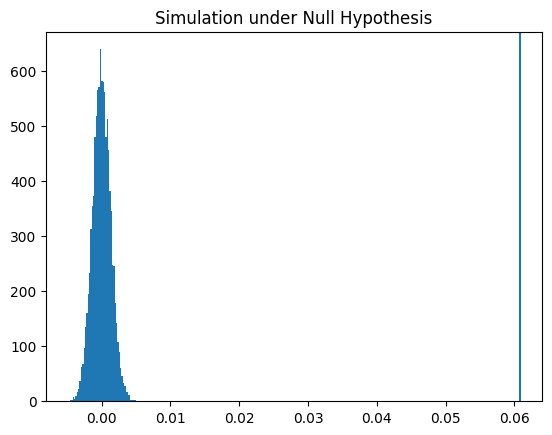

In [13]:
import matplotlib.pyplot as plt

plt.hist(sim_diffs, bins=50)
plt.axvline(observed_diff)
plt.title("Simulation under Null Hypothesis")
plt.show()

##  Visual Interpretation

The histogram shows the distribution of differences generated under the assumption that there is no real effect.

###  Key Observations:

- The distribution is centered around 0, indicating no difference  
- The observed difference lies far outside this distribution  

###  Conclusion:

The observed result is extremely unlikely to occur due to randomness alone, reinforcing the conclusion that the treatment effect is real.

##  Power Analysis

While hypothesis testing tells us whether an effect is significant, it is also important to understand the ability of the test to detect a real effect.

###  Definition:
**Power** is the probability of correctly detecting a true effect when it actually exists.

{Power} = P({Reject H_0} / {H_1 is true})


###  Intuition:
- High power → we are likely to detect real differences  
- Low power → we may miss real effects  

###  Why it matters:
A non-significant result may occur either because:
- There is no real effect  
- OR the sample size is too small (low power)

Therefore, power analysis helps evaluate the reliability of our conclusions.

In [14]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

effect_size = proportion_effectsize(p_control, p_treatment)

analysis = NormalIndPower()

power = analysis.power(
    effect_size=effect_size,
    nobs1=nobs['control'],
    alpha=0.05,
    ratio=nobs['treatment']/nobs['control']
)

print("Power:", power)

Power: 1.0


##  Interpretation of Power

The computed power of the test is approximately **1 (or very close to 1)**.

###  Interpretation:

- A power close to 1 means there is an **almost 100% chance of detecting a real effect**
- This indicates that the test is extremely reliable

###  Why is power so high?

- The dataset has a very large sample size (~300,000 users)  
- The observed effect size (~6%) is substantial  

###  Conclusion:

The combination of large sample size and strong effect ensures that the probability of missing a real effect is extremely low.

###  Key Takeaway:

This confirms that the observed difference is both statistically significant and reliably detectable, strengthening the confidence in the results.

In [15]:
df.groupby(['gender','group'])['converted'].mean().unstack()

group,control,treatment
gender,,
Female,0.118258,0.178432
Male,0.118870,0.180569
Other,0.126565,0.178878


In [16]:
df.groupby(['device_type','group'])['converted'].mean().unstack()

group,control,treatment
device_type,,
Desktop,0.119495,0.180826
Mobile,0.117436,0.177132
Tablet,0.118471,0.180084


##  Segmentation Insights

###  Gender-Based Analysis

The conversion rates across gender segments are as follows:

- Female: Control = 11.82%, Treatment = 17.84%  
- Male: Control = 11.89%, Treatment = 18.06%  
- Other: Control = 12.66%, Treatment = 17.89%  

###  Insight:

- The treatment group shows a consistent improvement across all genders  
- The increase in conversion rate is approximately **5–6% across segments**  
- The effect is slightly stronger for male users and slightly lower for the “Other” category  

---

###  Device-Based Analysis

The conversion rates across device types are:

- Desktop: Control = 11.95%, Treatment = 18.08%  
- Mobile: Control = 11.74%, Treatment = 17.71%  
- Tablet: Control = 11.85%, Treatment = 18.01%  

###  Insight:

- The improvement is consistent across all device types  
- The treatment increases conversion rates by approximately **6% across all platforms**  
- This indicates that the new design performs well across different devices  

---

###  Key Takeaway:

The treatment effect is **robust and consistent across different user segments**, suggesting that the improvement is not limited to a specific group but is broadly applicable.

---

###  Business Implication:

Since the improvement is consistent across:
- Genders  
- Devices  

The new design can be confidently deployed to all users without the need for segment-specific customization.

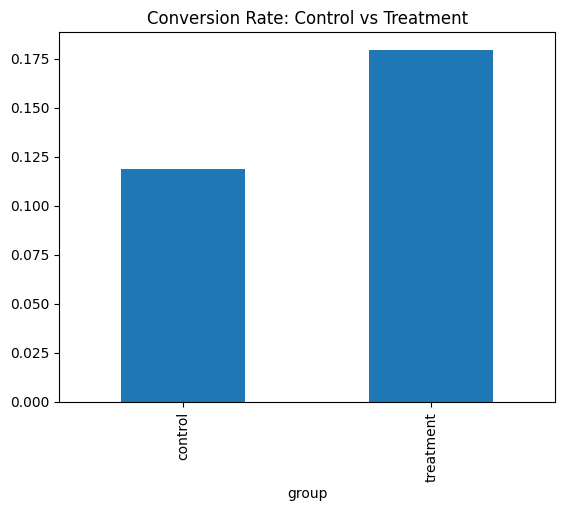

In [17]:
df.groupby('group')['converted'].mean().plot(kind='bar')
plt.title("Conversion Rate: Control vs Treatment")
plt.show()

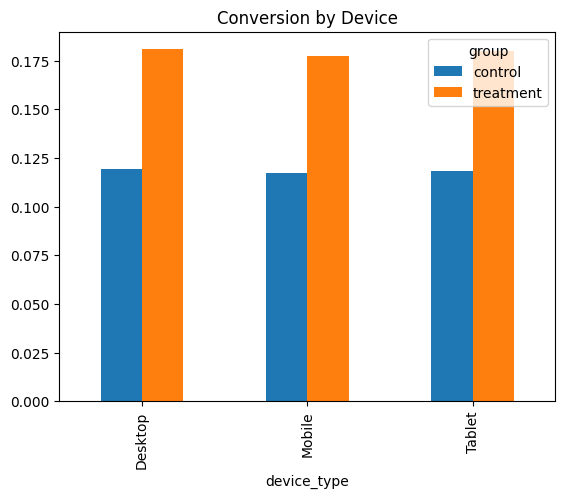

In [18]:
df.groupby(['device_type','group'])['converted'].mean().unstack().plot(kind='bar')
plt.title("Conversion by Device")
plt.show()

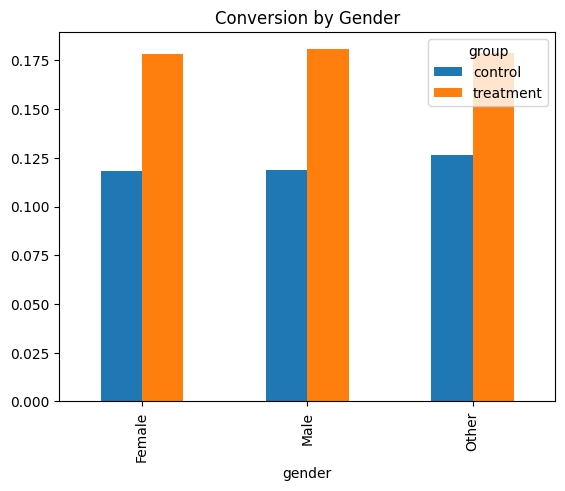

In [19]:
df.groupby(['gender','group'])['converted'].mean().unstack().plot(kind='bar')
plt.title("Conversion by Gender")
plt.show()

## 📊 Business Insights from A/B Testing

The analysis shows that the treatment group (new page design) achieved a significantly higher conversion rate compared to the control group (old page design). The observed improvement in conversion rate is approximately **6%**, which is both statistically significant and practically meaningful.

From a business perspective, this improvement can have a substantial impact at scale. For example, if the platform receives **100,000 users**, a 6% increase in conversion rate would result in approximately **6,000 additional conversions**. Depending on the average revenue per conversion, this could translate into a significant increase in overall revenue.

The statistical analysis (p-value ≈ 0 and confidence interval entirely above 0) confirms that this improvement is not due to random chance, but represents a **real and reliable effect** of the new design.

###  Key Takeaways:
- The new design (treatment) outperforms the old design (control)
- The improvement is both **statistically significant** and **business-relevant**
- Scaling this change can lead to **substantial revenue growth**

###  Recommendation:
Based on the analysis, it is recommended to **deploy the new design to all users**, as it is expected to improve conversion rates and overall business performance.